In [1]:
import sys
sys.path.append('/home/hli54/Projects/RL-bandit') # Add current directory to the python path

from components import *
from utils import *
import numpy as np
from tqdm import tqdm

In [2]:
K = 10
EPSILON_LS = [0, 0.01, 0.1]
T = 1000
N_TRIALS = 2000

In [3]:
policy_ls = [
    EpsilonPolicy(K, epsilon) for epsilon in EPSILON_LS
]
env = K_Bandit_Env(K)

sim = K_Bandit_Simulation(policy_ls, env)

In [4]:
best_choice, action_history, reward_history = sim.one_simulation_run(T)

In [5]:
reward_records = [
    [] for _ in EPSILON_LS
]
action_records = [
    [] for _ in EPSILON_LS
]
best_choice_records = []

for _ in tqdm(range(N_TRIALS)):
    best_choice, action_history, reward_history = sim.one_simulation_run(T)
    for policy_idx in range(len(EPSILON_LS)):
        action_records[policy_idx].append(action_history[policy_idx])
        reward_records[policy_idx].append(reward_history[policy_idx])
    best_choice_records.append(best_choice)

100%|██████████| 2000/2000 [02:25<00:00, 13.76it/s]


In [6]:
total_rewards = [
    np.average(rewards, axis=0) for rewards in reward_records
]

In [7]:
running_acumulative_rewards = [
    running_average(rewards) for rewards in total_rewards
]

In [8]:
type(action_records[0])

list

In [9]:
best_choice_records_arr = np.array(best_choice_records)
best_choice_records_arr = best_choice_records_arr.repeat(T).reshape(N_TRIALS, T)
is_accurate_action = [
    best_choice_records_arr == np.array( actions ) for actions in action_records
]
prob_accurate_action = [
    np.average(actions, axis=0) for actions in is_accurate_action
]

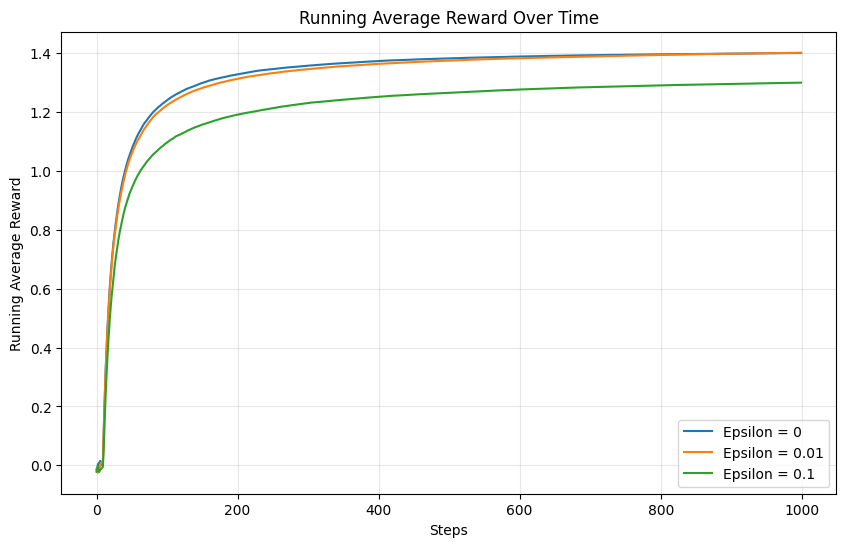

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Replace this with your actual labels if you have them
labels = [f'Epsilon = {epsilon}' for epsilon in EPSILON_LS]

for i, data in enumerate(running_acumulative_rewards):
    # running_avg = np.cumsum(data) / np.arange(1, len(data) + 1)
    
    plt.plot(data, label=labels[i])

plt.xlabel('Steps')
plt.ylabel('Running Average Reward')
plt.title('Running Average Reward Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


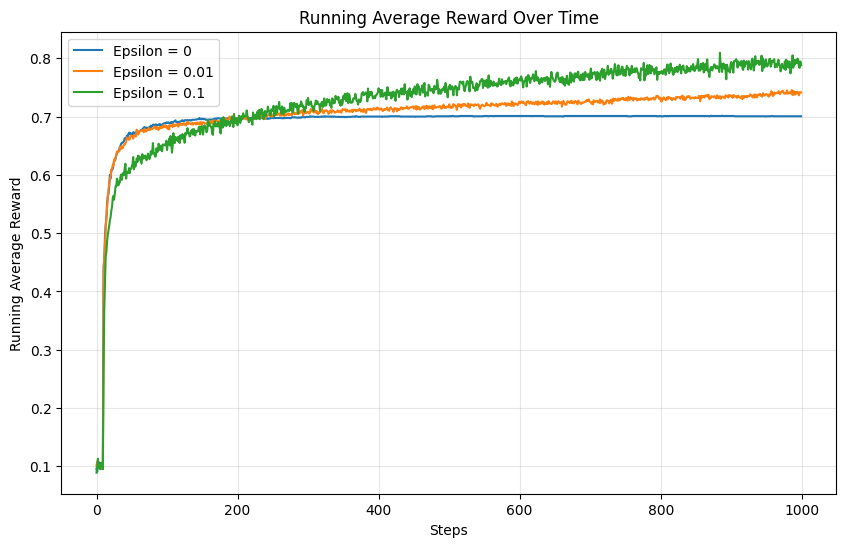

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Replace this with your actual labels if you have them
labels = [f'Epsilon = {epsilon}' for epsilon in EPSILON_LS]

for i, data in enumerate(prob_accurate_action):
    plt.plot(data, label=labels[i])
    

plt.xlabel('Steps')
plt.ylabel('Running Average Reward')
plt.title('Running Average Reward Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


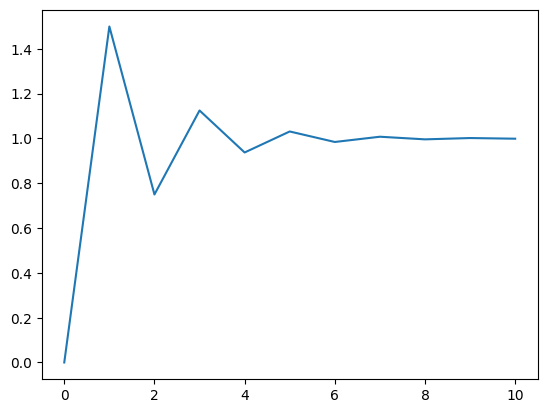

In [20]:
ALPHA = 1.5
o_ls = [0]
for _ in range(10):
    o_ls.append( o_ls[-1] + ALPHA * (1 - o_ls[-1]) )

plt.plot(o_ls)